# AICL 3605 - Computer Vision Lab
**Author:** Muhammad Haroon  
**Registration Number:** 23108124  
**Lab Session:** LAB 05: Implementation on Edge Detection


**1: Sobel Edge Detection**

In [2]:
# Install OpenCV if not installed
!pip install opencv-python-headless --quiet
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
#step 1: upload image
print("Upload a road or lane image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Upload a road or lane image:


Saving download.jpg to download.jpg


In [4]:
#step 2: Read image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

In [5]:
# Step 3: Apply Sobel operator to detect edges
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) # horizontal edges
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) # vertical edges

In [6]:
# step 3.1 Calculate gradient magnitude
sobel_magnitude = cv2.magnitude(sobelx, sobely)

In [7]:
# step 3.2 Normalize to 0-255 for display
sobel_norm = np.uint8(255 * sobel_magnitude / np.max(sobel_magnitude))

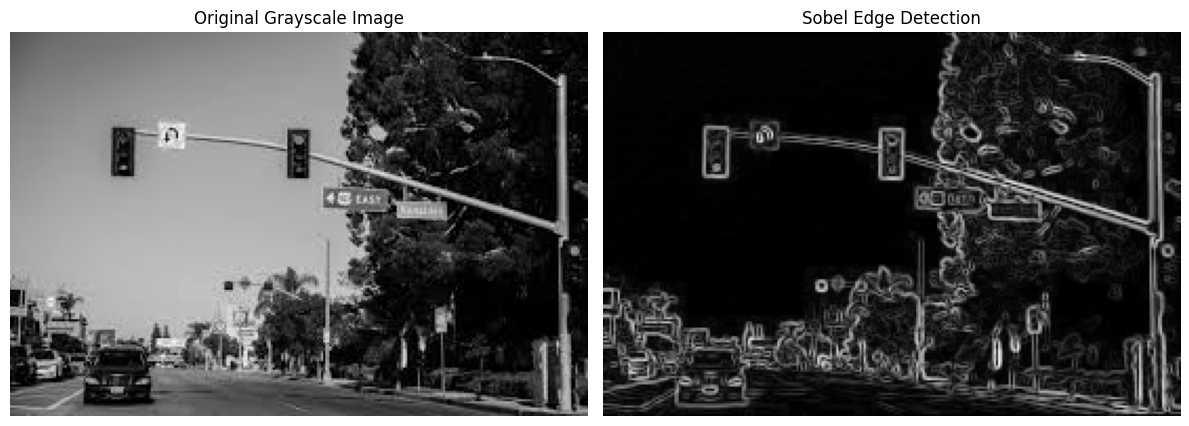

In [8]:
# Step 4: Plot original and Sobel edge image
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sobel_norm, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis('off')
plt.tight_layout()
plt.show()

**2: Prewitt Edge Detection**

In [9]:
# Step 1: Upload aerial image
print("Upload an aerial or satellite image (preferably grayscale or color):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]


Upload an aerial or satellite image (preferably grayscale or color):


Saving 1_Bv_G0ttTXTLAvIB4sJuqeA.png to 1_Bv_G0ttTXTLAvIB4sJuqeA.png


In [10]:
# Step 2: Read image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


In [11]:
# Step 3: Define Prewitt kernels
kernelx = np.array([[1, 0, -1],
          [1, 0, -1],
          [1, 0, -1]], dtype=np.float32)

kernely = np.array([[1, 1, 1],
          [0, 0, 0],
          [-1, -1, -1]], dtype=np.float32)


In [12]:
# Step 4: Apply Prewitt filter using filter2D
img_prewittx = cv2.filter2D(img, -1, kernelx)
img_prewitty = cv2.filter2D(img, -1, kernely)

# Combine horizontal and vertical edges
prewitt = cv2.addWeighted(img_prewittx, 0.5, img_prewitty, 0.5, 0)


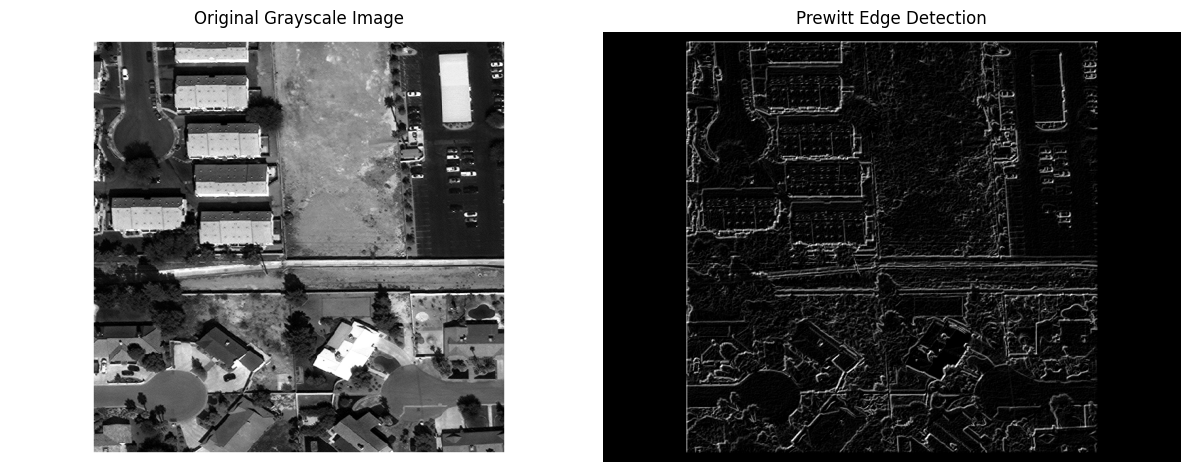

In [13]:
# Step 5: Display images
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt Edge Detection")
plt.axis('off')
plt.tight_layout()
plt.show()

**3: Canny Edge Detection**

In [14]:
# Step 1: Upload an image (traffic sign or similar)
print("Upload an image of a traffic sign or street scene:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]


Upload an image of a traffic sign or street scene:


Saving download.jpg to download (1).jpg


In [15]:
# Step 2: Read image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

In [16]:
# Step 3: Apply Canny edge detector
edges = cv2.Canny(img, threshold1=100, threshold2=200)

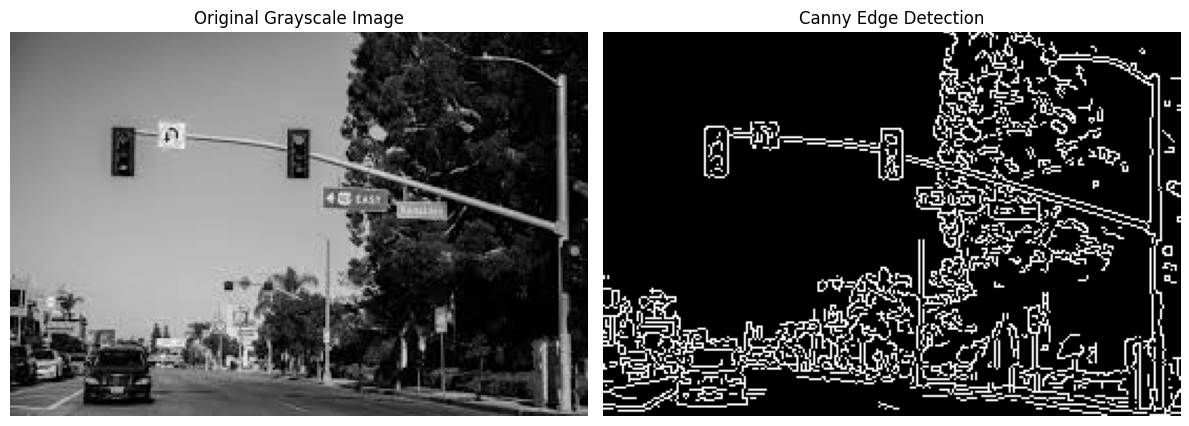

In [17]:
# Step 4: Display original and edge images side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study 1: Medical Image Edge Detection (CT/MRI Scans)**

In medical imaging, radiologists use CT or MRI scans to analyze internal organs and tissues. Edge
detection is used to highlight boundaries of tumors, segment organs, or detect anomalies. Canny edge
detection is particularly useful due to its ability to suppress noise while retaining clear, thin edges.

In [18]:
print("Upload a grayscale medical image (e.g. CT or MRI scan):")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]


Upload a grayscale medical image (e.g. CT or MRI scan):


Saving images.jpg to images.jpg


In [19]:
#Reading the image in grayscale
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [21]:
#Applying Canny edge detection
edges = cv2.Canny(img, 50, 150)

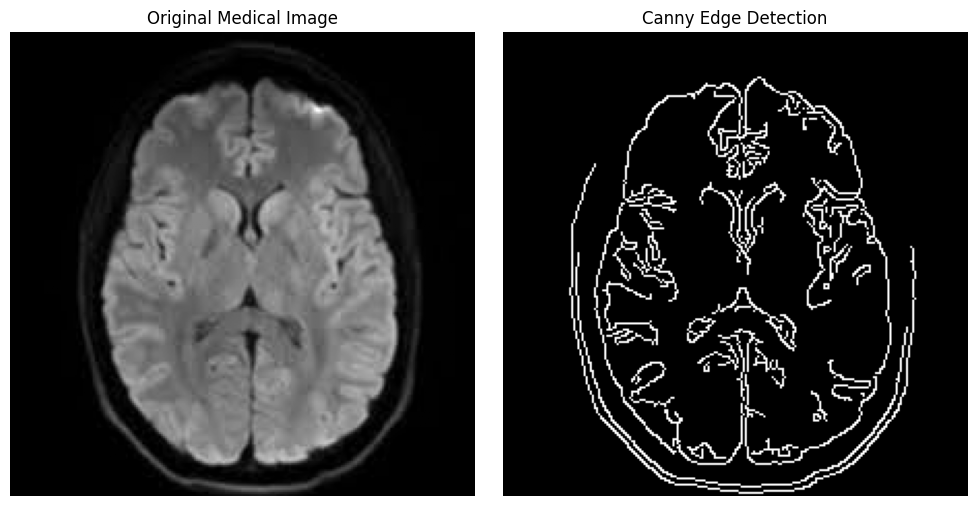

In [22]:
#Display the original and edge images

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Medical Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study 2: Road and Lane Detection in Autonomous Vehicles**

Self-driving vehicles use front-facing cameras to identify lane boundaries, road edges, and traffic
signs. Canny edge detection acts as a preprocessing step to simplify the image and extract significant
geometric features like white lines, which represent lanes.

In [23]:
print("Upload a road image with visible lane lines:")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Upload a road image with visible lane lines:


Saving grayscale-part-interstate-located-pomona-california-grayscale-part-interstate-located-pomona-258866086.webp to grayscale-part-interstate-located-pomona-california-grayscale-part-interstate-located-pomona-258866086.webp


In [24]:
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [25]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

In [26]:
edges = cv2.Canny(blurred, 50, 150)

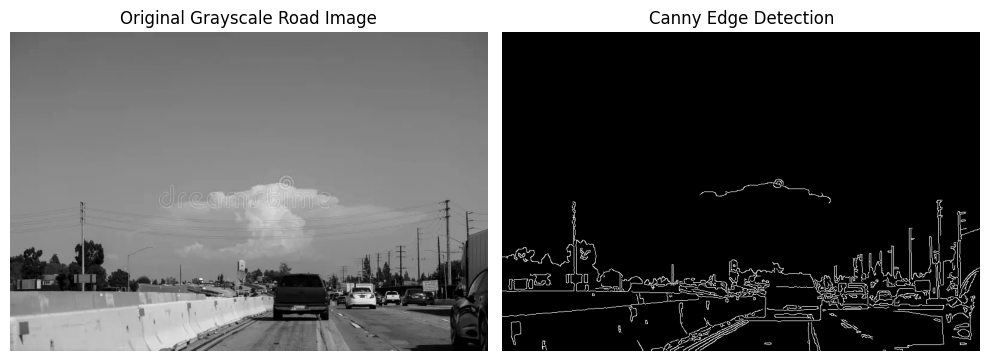

In [27]:
#Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Road Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.tight_layout()
plt.show()